In [ ]:
import math
import random
import torch
from torch import Tensor, nn
from torch.nn import functional as F
from torch.utils.data import DataLoader, Dataset
from pathlib import Path

SEED = 7
DATA_DIR = Path('shakespeare-dataset-main/text')
BLOCK_SIZE, BATCH_SIZE, NUM_WORKERS = 64, 128, 0
DIM, NUM_LAYERS, NUM_HEADS, FF_DIM, DROPOUT = 16, 6, 4, 512, 0.1
DIFFUSION_STEPS, BETA_START, BETA_END = 1000, 1e-4, 0.02
LEARNING_RATE, WEIGHT_DECAY, GRAD_CLIP_NORM = 3e-4, 1e-2, 1.0
TRAIN_STEPS, LOG_EVERY, SAMPLE_EVERY = 10_000, 50, 1_000
CE_WEIGHT, PRIOR_WEIGHT = 1.0, 10.0
PRIOR_SAMPLES, PRIOR_PROJECTIONS = 1_024, 32
SAMPLE_BATCH_SIZE, SAMPLE_REVERSE_STEPS = 2, 250

device = torch.device('mps' if torch.backends.mps.is_available() else 'cuda' if torch.cuda.is_available() else 'cpu')
torch.manual_seed(SEED)
random.seed(SEED)
print(f'Using {device}')


Using mps


In [20]:
def clean_folger_text(raw):
    lines = raw.replace('\r\n', '\n').replace('\r', '\n').splitlines(keepends=True)
    return ''.join(lines[7:]).lstrip('\n')

paths = sorted(DATA_DIR.glob('*.txt'))
if not paths:
    raise FileNotFoundError(f'No .txt files in {DATA_DIR}')
text = '\n\n'.join(clean_folger_text(p.read_text(encoding='utf-8')) for p in paths)
chars = sorted(set(text))
stoi = {char: index for index, char in enumerate(chars)}
itos = dict(enumerate(chars))
tokens = torch.tensor([stoi[c] for c in text], dtype=torch.long)
token_probabilities = (torch.bincount(tokens, minlength=len(chars)) / len(tokens)).to(device)

class CharacterBlocks(Dataset):
    def __init__(self, values, block_size):
        self.values = values
        self.block_size = block_size
    def __len__(self): return len(self.values) // self.block_size
    def __getitem__(self, index):
        start = index * self.block_size
        return self.values[start:start + self.block_size]

dataset = CharacterBlocks(tokens, BLOCK_SIZE)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True, drop_last=True, num_workers=NUM_WORKERS)
print(f'Loaded {len(paths)} works | {len(text):,} characters | vocab={len(chars)} | batch={tuple(next(iter(loader)).shape)}')


Loaded 42 works | 5,319,139 characters | vocab=84 | batch=(128, 64)


In [21]:
class GaussianEmbedding(nn.Module):
    def __init__(self, vocab_size, dim):
        super().__init__()
        token_var = 0.05
        mean_var = 1.0 - token_var

        std_init = math.sqrt(token_var)
        raw_std_init = math.log(math.expm1(std_init))

        self.mu = nn.Parameter(torch.randn(vocab_size, dim) * math.sqrt(mean_var))
        self.raw_std = nn.Parameter(torch.full((vocab_size, dim), raw_std_init))
    @property
    def std(self):
        return F.softplus(self.raw_std)
    def sample(self, ids):
        mean = self.mu[ids]
        return mean + self.std[ids] * torch.randn_like(mean)
    def log_probs(self, vectors):
        std = self.std
        precision = std.square().reciprocal()
        weighted_means = self.mu * precision
        mahalanobis = (
            vectors.square() @ precision.T
            - 2 * (vectors @ weighted_means.T)
            + (self.mu.square() * precision).sum(-1)
        )
        log_density = -0.5 * mahalanobis - std.log().sum(-1)
        return F.log_softmax(log_density, dim=-1)

# Model 
class SimpleGaussianDiffusionLM(nn.Module):
    def __init__(self, vocab_size):
        super().__init__()
        self.embedding = GaussianEmbedding(vocab_size, DIM)
        self.position = nn.Embedding(BLOCK_SIZE, DIM)

        frequencies = torch.exp(-math.log(10_000) * torch.arange(DIM // 2) / (DIM // 2))
        self.register_buffer('time_frequencies', frequencies)
        layer = nn.TransformerEncoderLayer(DIM, NUM_HEADS, FF_DIM, DROPOUT, batch_first=True, norm_first=False, activation='gelu')
        self.transformer = nn.TransformerEncoder(layer, NUM_LAYERS)
        self.final_norm, self.x0_head = nn.LayerNorm(DIM), nn.Linear(DIM, DIM)
    def forward(self, x_t, timesteps):
        pos = torch.arange(x_t.size(1), device=x_t.device)
        angles = timesteps[:, None] * self.time_frequencies
        time_embedding = torch.cat((angles.sin(), angles.cos()), dim=-1)
        hidden = x_t + self.position(pos).unsqueeze(0) + time_embedding.unsqueeze(1)
        return self.x0_head(self.final_norm(self.transformer(hidden)))
    def rounding_log_probs(self, vectors): return self.embedding.log_probs(vectors)
    def round_to_tokens(self, vectors): return self.rounding_log_probs(vectors).argmax(-1)

model = SimpleGaussianDiffusionLM(len(chars)).to(device)
print(f'Parameters: {sum(p.numel() for p in model.parameters()):,}')


Parameters: 112,400


In [22]:
betas = torch.linspace(BETA_START, BETA_END, DIFFUSION_STEPS, device=device)
alpha_bar = torch.cat((torch.ones(1, device=device), torch.cumprod(1 - betas, 0)))

def q_sample(x0, t):
    alpha = alpha_bar[t].view(-1, 1, 1)
    return alpha.sqrt() * x0 + (1 - alpha).sqrt() * torch.randn_like(x0)

def sliced_wasserstein_loss(x0):
    values = x0.reshape(-1, DIM)
    sample = values[torch.randperm(len(values), device=values.device)[:PRIOR_SAMPLES]]
    directions = F.normalize(torch.randn(DIM, PRIOR_PROJECTIONS, device=values.device), dim=0)
    projected = sample @ directions
    normal = torch.randn_like(projected)
    return (projected.sort(dim=0).values - normal.sort(dim=0).values).square().mean()


@torch.no_grad()
def embedding_diagnostics():
    probabilities = token_probabilities[:, None]
    means = model.embedding.mu
    variances = model.embedding.std.square()
    mean = (probabilities * means).sum(0)
    centered = means - mean
    between_covariance = (probabilities * centered).T @ centered
    within_diagonal = (probabilities * variances).sum(0)
    covariance = between_covariance + torch.diag(within_diagonal)
    return {
        'mean_avg': mean.mean().item(),
        'mean_rms': mean.square().mean().sqrt().item(),
        'variance_avg': covariance.diagonal().mean().item(),
        'within_variance': within_diagonal.mean().item(),
        'between_variance': between_covariance.diagonal().mean().item(),
        'cov_rms_error': (
            torch.linalg.matrix_norm(covariance - torch.eye(DIM, device=device))
            / math.sqrt(DIM)
        ).item(),
    }


def loss_terms(ids):
    # One Gaussian embedding draw and one denoising prediction per training example.
    x0 = model.embedding.sample(ids)
    t = torch.randint(1, DIFFUSION_STEPS + 1, (ids.size(0),), device=device)
    prediction = model(q_sample(x0, t), t)
    token_ce = F.nll_loss(
        model.rounding_log_probs(prediction).flatten(0, 1), ids.flatten()
    )
    weighted_prior = PRIOR_WEIGHT * sliced_wasserstein_loss(x0)
    # Uniform CE across timesteps; no MSE, clean-embedding CE, or detached embeddings.
    total = CE_WEIGHT * token_ce + weighted_prior
    return total, token_ce, weighted_prior


optimizer = torch.optim.AdamW(model.parameters(), lr=LEARNING_RATE, weight_decay=WEIGHT_DECAY)
completed_steps = 0  # Reset together with the optimizer; train() calls accumulate updates.

# Capture the configuration for this fresh run, rather than relying on the filename.
# After changing settings, rerun from the top to initialize a matching model/optimizer.
OBJECTIVE = 'noisy_token_ce_plus_sliced_wasserstein_prior'
CONFIG_NAMES = (
    'SEED', 'DATA_DIR', 'BLOCK_SIZE', 'BATCH_SIZE', 'NUM_WORKERS',
    'DIM', 'NUM_LAYERS', 'NUM_HEADS', 'FF_DIM', 'DROPOUT',
    'DIFFUSION_STEPS', 'BETA_START', 'BETA_END',
    'LEARNING_RATE', 'WEIGHT_DECAY', 'GRAD_CLIP_NORM',
    'TRAIN_STEPS', 'LOG_EVERY', 'SAMPLE_EVERY', 'CE_WEIGHT', 'PRIOR_WEIGHT',
    'PRIOR_SAMPLES', 'PRIOR_PROJECTIONS', 'SAMPLE_BATCH_SIZE', 'SAMPLE_REVERSE_STEPS',
)
run_config = {
    name.lower(): str(globals()[name]) if isinstance(globals()[name], Path) else globals()[name]
    for name in CONFIG_NAMES
}
run_config.update({
    'objective': OBJECTIVE,
    'source_notebook': 'gauss_embedd_dlm_wass.ipynb',
    'experiment_notebook': 'gauss_embed_dlm_wass_ce.ipynb',
    'initialization': 'fresh',
    'embedding_initial_token_variance': 0.05,
    'embedding_initial_mean_variance': 0.95,
    'embedding_std_parameterization': 'softplus',
    'decoder': 'Gaussian log density followed by log_softmax; no temperature scaling',
    'norm_first': False,
    'activation': 'gelu',
    'noise_schedule': 'linear_beta',
    'timestep_sampling': 'uniform integers 1..DIFFUSION_STEPS, one per sequence',
    'ce_timestep_weighting': 'uniform',
    'sampler': 'deterministic DDIM, no clamping',
    'optimizer': 'AdamW',
    'optimizer_defaults': dict(optimizer.defaults),
    'data_files': [str(path) for path in paths],
    'data_cleaning': 'normalize newlines, remove first 7 lines per work, join with two newlines',
    'data_split': 'all works; reconstruction diagnostics use training blocks',
    'corpus_characters': len(tokens),
    'vocab_size': len(chars),
    'parameters': sum(p.numel() for p in model.parameters()),
    'device': str(device),
    'torch_version': str(torch.__version__),
})


In [23]:
def step(batch):
    global completed_steps
    optimizer.zero_grad(set_to_none=True)
    values = loss_terms(batch.to(device))
    if not torch.isfinite(values[0]).item():
        raise FloatingPointError('Non-finite CE/prior loss; optimizer was not updated.')
    values[0].backward()
    grad_norm = torch.nn.utils.clip_grad_norm_(
        model.parameters(), GRAD_CLIP_NORM, error_if_nonfinite=True
    )
    optimizer.step()
    completed_steps += 1
    return *values, grad_norm


def train(steps=TRAIN_STEPS):
    model.train()
    iterator = iter(loader)
    running = torch.zeros(4)
    window_steps = 0
    for number in range(1, steps + 1):
        try: batch = next(iterator)
        except StopIteration:
            iterator = iter(loader)
            batch = next(iterator)
        values = step(batch)
        running += torch.tensor([value.item() for value in values])
        window_steps += 1
        if number % LOG_EVERY == 0 or number == steps:
            mean = running / window_steps
            geometry = embedding_diagnostics()
            print(
                f'step {number}/{steps} | completed_steps={completed_steps} | '
                f'total={mean[0]:.4f} | token_ce={mean[1]:.4f} | '
                f'weighted_prior={mean[2]:.6f} | grad_norm={mean[3]:.4f} | '
                + ' | '.join(f'{name}={value:.4f}' for name, value in geometry.items())
            )
            running.zero_()
            window_steps = 0
        if number % SAMPLE_EVERY == 0:
            print(f'\nSamples after {completed_steps} optimizer steps:')
            blocks, norms = sample(return_norms=True)
            for row in norms:
                print(
                    f"t={row['t']} -> {row['next_t']} | "
                    f"pred_norm²/d={row['pred_norm']:.4f} | "
                    f"state_norm²/d={row['state_norm']:.4f}"
                )
            for token_block in blocks.cpu():
                print(''.join(itos[token.item()] for token in token_block))
                print()


In [24]:
@torch.no_grad()
def sample(batch_size=SAMPLE_BATCH_SIZE, reverse_steps=SAMPLE_REVERSE_STEPS, return_norms=False):
    if not 1 <= reverse_steps <= DIFFUSION_STEPS:
        raise ValueError('reverse_steps must be between 1 and DIFFUSION_STEPS')
    was_training = model.training
    model.eval()
    try:
        x_t = torch.randn(batch_size, BLOCK_SIZE, DIM, device=device)
        norms = []
        trace_steps = {1, reverse_steps // 2, reverse_steps * 9 // 10, reverse_steps}
        times = torch.linspace(DIFFUSION_STEPS, 0, reverse_steps + 1, device=device).long()
        for number, (current, next_time) in enumerate(zip(times[:-1], times[1:]), 1):
            t = torch.full((batch_size,), int(current.item()), device=device, dtype=torch.long)
            x0_hat = model(x_t, t)
            # Same deterministic reverse update as the source experiment.
            # CE does not guarantee that x0_hat is a calibrated clean-vector estimate.
            a_t, a_next = alpha_bar[current], alpha_bar[next_time]
            eps_hat = (x_t - a_t.sqrt() * x0_hat) / (1 - a_t).sqrt().clamp_min(1e-8)
            x_t = a_next.sqrt() * x0_hat + (1 - a_next).sqrt() * eps_hat
            if return_norms and number in trace_steps:
                norms.append({
                    't': int(current.item()),
                    'next_t': int(next_time.item()),
                    'pred_norm': x0_hat.square().mean().item(),
                    'state_norm': x_t.square().mean().item(),
                })
        if not torch.isfinite(x_t).all().item():
            raise FloatingPointError('Non-finite final reverse state.')
        log_probs = model.rounding_log_probs(x_t)
        if not torch.isfinite(log_probs).all().item():
            raise FloatingPointError('Non-finite final Gaussian decoding scores.')
        result = log_probs.argmax(-1)
        return (result, norms) if return_norms else result
    finally:
        model.train(was_training)


# Running this cell starts the configured fresh 10,000-step experiment.
train()


step 50/10000 | completed_steps=50 | total=100.6068 | token_ce=89.4284 | weighted_prior=11.178400 | grad_norm=104.0254 | mean_avg=-0.0905 | mean_rms=0.2079 | variance_avg=1.1455 | within_variance=0.0511 | between_variance=1.0944 | cov_rms_error=1.0334
step 100/10000 | completed_steps=100 | total=68.0137 | token_ce=56.5500 | weighted_prior=11.463705 | grad_norm=45.4931 | mean_avg=-0.0894 | mean_rms=0.2072 | variance_avg=1.1233 | within_variance=0.0521 | between_variance=1.0712 | cov_rms_error=1.0066
step 150/10000 | completed_steps=150 | total=48.1309 | token_ce=37.5014 | weighted_prior=10.629522 | grad_norm=38.2785 | mean_avg=-0.0883 | mean_rms=0.2061 | variance_avg=1.1071 | within_variance=0.0529 | between_variance=1.0542 | cov_rms_error=0.9860
step 200/10000 | completed_steps=200 | total=35.3554 | token_ce=24.6129 | weighted_prior=10.742453 | grad_norm=31.5193 | mean_avg=-0.0870 | mean_rms=0.2034 | variance_avg=1.0952 | within_variance=0.0536 | between_variance=1.0416 | cov_rms_error

KeyboardInterrupt: 

In [28]:
blocks, norms = sample(return_norms=True)
for row in norms:
    print(
        f"t={row['t']} -> {row['next_t']} | pred_norm²/d={row['pred_norm']:.4f} | "
        f"state_norm²/d={row['state_norm']:.4f}"
    )
for token_block in blocks.cpu():
    print(''.join(itos[token.item()] for token in token_block))
    print()


t=1000 -> 996 | pred_norm²/d=0.4907 | state_norm²/d=0.9747
t=504 -> 500 | pred_norm²/d=0.4896 | state_norm²/d=0.9354
t=104 -> 100 | pred_norm²/d=0.4744 | state_norm²/d=0.5411
t=4 -> 0 | pred_norm²/d=0.4866 | state_norm²/d=0.4866
o Tnlul ovoyTutatioo  cooiaan oeu ku yv huv stonhesulsv  vvT
ovr

o Tnnul ovoyTusas oo  coo
aan oeTkku sv  uv stonhesulsv evvT
ovr



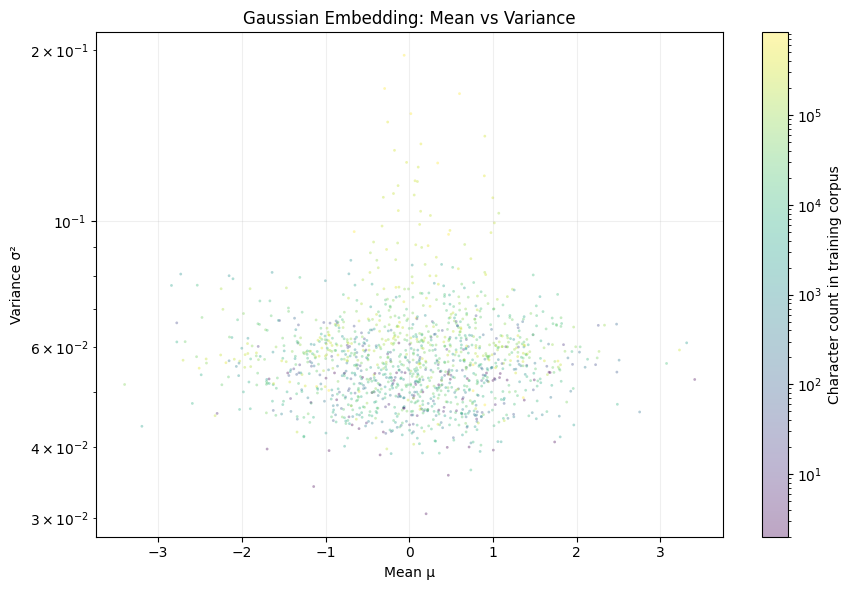

In [29]:
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm

mu = model.embedding.mu.detach().cpu()
variance = model.embedding.std.detach().square().cpu()

# Give each of a character's embedding dimensions the same frequency colour.
counts = torch.bincount(tokens, minlength=mu.shape[0]).cpu()
point_counts = counts.repeat_interleave(mu.shape[1])

fig, ax = plt.subplots(figsize=(9, 6))
points = ax.scatter(
    mu.flatten().numpy(),
    variance.flatten().numpy(),
    c=point_counts.numpy(),
    cmap="viridis",
    norm=LogNorm(vmin=max(1, counts.min().item()), vmax=counts.max().item()),
    s=4,
    alpha=0.35,
    linewidths=0,
)

ax.set_yscale("log")
ax.set_xlabel("Mean μ")
ax.set_ylabel("Variance σ²")
ax.set_title("Gaussian Embedding: Mean vs Variance")
ax.grid(alpha=0.2)
fig.colorbar(points, ax=ax, label="Character count in training corpus")
plt.tight_layout()
plt.show()

In [30]:
# These are training-corpus diagnostics, not held-out evaluation.
# Fixed blocks and locally seeded corruption permit paired checkpoint comparisons.
eval_generator = torch.Generator().manual_seed(1234)
eval_indices = torch.randperm(
    len(dataset), generator=eval_generator
)[:min(64, len(dataset))].tolist()
eval_blocks = torch.stack([dataset[i] for i in eval_indices])

@torch.no_grad()
def reconstruction_diagnostics(
    blocks=eval_blocks,
    timesteps=(1, 10, 100, 250, 500, 750, 1000),
    seed=1234,
):
    was_training = model.training
    model.eval()
    try:
        ids = blocks.to(device)
        noise_generator = torch.Generator().manual_seed(seed)
        def draw_noise(shape):
            return torch.randn(shape, generator=noise_generator).to(device)
        # One embedding sample reused across noise levels; never included as a CE loss target.
        x0 = model.embedding.mu[ids] + model.embedding.std[ids] * draw_noise((*ids.shape, DIM))
        clean_accuracy = (model.round_to_tokens(x0) == ids).float().mean().item()
        results = []
        for timestep in timesteps:
            if not 1 <= timestep <= DIFFUSION_STEPS:
                raise ValueError('Diagnostic timesteps must be within the training schedule')
            t = torch.full((ids.size(0),), timestep, device=device, dtype=torch.long)
            alpha = alpha_bar[t].view(-1, 1, 1)
            x_t = alpha.sqrt() * x0 + (1 - alpha).sqrt() * draw_noise(x0.shape)
            prediction = model(x_t, t)
            log_probs = model.rounding_log_probs(prediction)
            results.append({
                't': timestep,
                'token_ce': F.nll_loss(log_probs.flatten(0, 1), ids.flatten()).item(),
                'token_accuracy': (log_probs.argmax(-1) == ids).float().mean().item(),
                'pred_norm': prediction.square().mean().item(),
            })
        return {'clean_token_accuracy': clean_accuracy, 'timesteps': results}
    finally:
        model.train(was_training)


diagnostics = reconstruction_diagnostics()
print(f"Clean embedding token accuracy (diagnostic only): {diagnostics['clean_token_accuracy']:.1%}")
for row in diagnostics['timesteps']:
    print(
        f"t={row['t']:4d} | token_ce={row['token_ce']:.4f} | "
        f"token_accuracy={row['token_accuracy']:.1%} | pred_norm²/d={row['pred_norm']:.4f}"
    )
print('Embedding geometry | ' + ' | '.join(
    f'{name}={value:.4f}' for name, value in embedding_diagnostics().items()
))


Clean embedding token accuracy (diagnostic only): 100.0%
t=   1 | token_ce=0.1119 | token_accuracy=96.9% | pred_norm²/d=0.4586
t=  10 | token_ce=0.1107 | token_accuracy=97.0% | pred_norm²/d=0.4518
t= 100 | token_ce=0.1911 | token_accuracy=94.9% | pred_norm²/d=0.4551
t= 250 | token_ce=1.0363 | token_accuracy=71.8% | pred_norm²/d=0.4810
t= 500 | token_ce=2.9932 | token_accuracy=23.0% | pred_norm²/d=0.4900
t= 750 | token_ce=3.2971 | token_accuracy=16.3% | pred_norm²/d=0.4907
t=1000 | token_ce=3.3194 | token_accuracy=16.3% | pred_norm²/d=0.4908
Embedding geometry | mean_avg=-0.0145 | mean_rms=0.0412 | variance_avg=0.9823 | within_variance=0.0704 | between_variance=0.9119 | cov_rms_error=0.7104


In [32]:
@torch.no_grad()
def trace_reverse(start_noise, reverse_steps=10):
    if not 1 <= reverse_steps <= DIFFUSION_STEPS:
        raise ValueError('reverse_steps must be between 1 and DIFFUSION_STEPS')
    was_training = model.training
    model.eval()
    try:
        x_t = start_noise.clone()
        previous_output = None
        times = torch.linspace(DIFFUSION_STEPS, 0, reverse_steps + 1, device=device).long()
        for step, (current, next_time) in enumerate(zip(times[:-1], times[1:])):
            t = torch.full((x_t.size(0),), int(current.item()), device=device, dtype=torch.long)
            output = model(x_t, t)
            pred_norm = output.square().mean(dim=(1, 2))
            state_before = x_t.square().mean(dim=(1, 2))
            distance = (
                None if previous_output is None
                else (output - previous_output).square().mean(dim=(1, 2))
            )
            decoded = model.round_to_tokens(output).cpu()
            a_t, a_next = alpha_bar[current], alpha_bar[next_time]
            eps_hat = (x_t - a_t.sqrt() * output) / (1 - a_t).sqrt().clamp_min(1e-8)
            x_t = a_next.sqrt() * output + (1 - a_next).sqrt() * eps_hat
            if not torch.isfinite(x_t).all().item():
                raise FloatingPointError(f'Non-finite reverse state at timestep {next_time.item()}')
            state_after = x_t.square().mean(dim=(1, 2))
            print(f'\nstep {step} | t={current.item()} → {next_time.item()}')
            for i, block in enumerate(decoded):
                change = '—' if distance is None else f'{distance[i].item():.6f}'
                characters = ''.join(itos[token.item()] for token in block)
                print(
                    f'sample {i} | pred_norm²/d={pred_norm[i].item():.6f}'
                    f' | state_norm²/d={state_before[i].item():.6f} → {state_after[i].item():.6f}'
                    f' | prediction_change²/d={change} | {characters!r}'
                )
            previous_output = output
    finally:
        model.train(was_training)


trace_generator = torch.Generator().manual_seed(1234)
start_noise = torch.randn(SAMPLE_BATCH_SIZE, BLOCK_SIZE, DIM, generator=trace_generator).to(device)
trace_reverse(start_noise, reverse_steps=50)



step 0 | t=1000 → 980
sample 0 | pred_norm²/d=0.490836 | state_norm²/d=0.993998 → 0.993995 | prediction_change²/d=— | '                                                                '
sample 1 | pred_norm²/d=0.490792 | state_norm²/d=1.138854 → 1.138958 | prediction_change²/d=— | '                                                                '

step 1 | t=980 → 960
sample 0 | pred_norm²/d=0.490863 | state_norm²/d=0.993995 → 0.993988 | prediction_change²/d=0.000000 | '                                                                '
sample 1 | pred_norm²/d=0.490848 | state_norm²/d=1.138958 → 1.139078 | prediction_change²/d=0.000000 | '                                                                '

step 2 | t=960 → 940
sample 0 | pred_norm²/d=0.490887 | state_norm²/d=0.993988 → 0.993975 | prediction_change²/d=0.000000 | '                                                                '
sample 1 | pred_norm²/d=0.490895 | state_norm²/d=1.139078 → 1.139216 | prediction_change²/d=0.000

In [ ]:
checkpoint_path = Path('checkpoints/gauss_embed_dlm_wass_ce.pt')
checkpoint_path.parent.mkdir(parents=True, exist_ok=True)

torch.save({
    'model': model.state_dict(),
    'optimizer': optimizer.state_dict(),
    'chars': chars,
    'dim': DIM,
    'config': run_config,
    'objective': OBJECTIVE,
    'completed_steps': completed_steps,
}, checkpoint_path)
print(f'Saved {checkpoint_path.resolve()} after {completed_steps} completed optimizer steps')


In [38]:

@torch.no_grad()
def sample_ce_posterior(
    batch_size=SAMPLE_BATCH_SIZE,
    reverse_steps=SAMPLE_REVERSE_STEPS,
    seed=1234,
    use_posterior=True,
):
    if not 1 <= reverse_steps <= DIFFUSION_STEPS:
        raise ValueError("reverse_steps must be within the diffusion schedule")

    was_training = model.training
    model.eval()

    try:
        means = model.embedding.mu                 # [vocab, dim]
        variances = model.embedding.std.square()   # [vocab, dim]
        sample_device = means.device

        # Local generator: paired samples without changing training RNG state.
        generator = torch.Generator(device="cpu").manual_seed(seed)
        x_t = torch.randn(
            batch_size, BLOCK_SIZE, means.shape[-1],
            generator=generator,
            dtype=means.dtype,
        ).to(sample_device)

        schedule = alpha_bar.to(device=sample_device, dtype=means.dtype)
        times = torch.linspace(
            DIFFUSION_STEPS, 0, reverse_steps + 1
        ).long().tolist()

        trace = []
        trace_steps = {
            1,
            max(1, reverse_steps // 2),
            max(1, reverse_steps * 9 // 10),
            reverse_steps,
        }

        for step, (current, next_time) in enumerate(
            zip(times[:-1], times[1:]), start=1
        ):
            t = torch.full(
                (batch_size,), current,
                device=sample_device, dtype=torch.long,
            )
            raw_prediction = model(x_t, t)
            a_t = schedule[current]
            a_next = schedule[next_time]

            if use_posterior:
                # The CE-trained decoder estimates token probabilities.
                probabilities = model.rounding_log_probs(
                    raw_prediction
                ).exp()                           # [batch, length, vocab]

                # q(x_t | w) has variance a_t * variance_w + (1 - a_t).
                denominator = a_t * variances + (1 - a_t)

                # E[x0 | x_t, w] = intercept_w + gain_w * x_t.
                gain = a_t.sqrt() * variances / denominator
                intercept = (1 - a_t) * means / denominator

                # Average conditional clean estimates over token probabilities.
                # Matrix products avoid a [batch, length, vocab, dim] tensor.
                x0_hat = (
                    probabilities @ intercept
                    + x_t * (probabilities @ gain)
                )
            else:
                # Original interpretation, for a paired comparison.
                x0_hat = raw_prediction

            # Original deterministic DDIM update.
            eps_hat = (
                x_t - a_t.sqrt() * x0_hat
            ) / (1 - a_t).sqrt().clamp_min(1e-8)

            x_t = (
                a_next.sqrt() * x0_hat
                + (1 - a_next).sqrt() * eps_hat
            )

            if step in trace_steps:
                trace.append({
                    "t": current,
                    "next_t": next_time,
                    "raw_norm": raw_prediction.square().mean().item(),
                    "used_x0_norm": x0_hat.square().mean().item(),
                    "state_norm": x_t.square().mean().item(),
                })

        if not torch.isfinite(x_t).all().item():
            raise FloatingPointError("Non-finite final reverse state")

        # Preserve the original final Gaussian decoder.
        final_log_probs = model.rounding_log_probs(x_t)
        if not torch.isfinite(final_log_probs).all().item():
            raise FloatingPointError("Non-finite final decoding probabilities")

        return final_log_probs.argmax(-1), trace

    finally:
        model.train(was_training)


# Same model, seed, batch size, reverse steps, and final decoder.
# Only the continuous estimate supplied to DDIM changes.
for use_posterior in (False, True):
    label = "Original raw-vector sampler" if not use_posterior else "Posterior-mean sampler"
    blocks, trace = sample_ce_posterior(
        batch_size=2,
        reverse_steps=SAMPLE_REVERSE_STEPS,
        seed=torch.randint(0, 2**32 - 1, (1,)).item(),
        use_posterior=use_posterior,
    )

    print(f"\n{'=' * 20} {label} {'=' * 20}")
    for row in trace:
        print(
            f"t={row['t']:4d} → {row['next_t']:4d} | "
            f"raw_norm²/d={row['raw_norm']:.6f} | "
            f"used_x0_norm²/d={row['used_x0_norm']:.6f} | "
            f"state_norm²/d={row['state_norm']:.6f}"
        )

    for block in blocks.cpu().tolist():
        print(repr("".join(itos[token] for token in block)))


==================== Original raw-vector sampler ====================
t=1000 →  996 | raw_norm²/d=0.490782 | used_x0_norm²/d=0.490782 | state_norm²/d=0.974030
t= 504 →  500 | raw_norm²/d=0.490418 | used_x0_norm²/d=0.490418 | state_norm²/d=0.926994
t= 104 →  100 | raw_norm²/d=0.475922 | used_x0_norm²/d=0.475922 | state_norm²/d=0.533124
t=   4 →    0 | raw_norm²/d=0.486595 | used_x0_norm²/d=0.486595 | state_norm²/d=0.486595
'o Tnlul vvoyTutas oo vcoo\naan oeukkT sv  uv stouhisulsv  vvT\novr'
'o Tnlul vvoyTusas oo vcoo\naan o vkkT sv  uv stonhesulsv evvT\novr'

==================== Posterior-mean sampler ====================
t=1000 →  996 | raw_norm²/d=0.490762 | used_x0_norm²/d=0.006951 | state_norm²/d=0.992164
t= 504 →  500 | raw_norm²/d=0.490028 | used_x0_norm²/d=0.107664 | state_norm²/d=0.965177
t= 104 →  100 | raw_norm²/d=0.452616 | used_x0_norm²/d=0.910272 | state_norm²/d=0.874618
t=   4 →    0 | raw_norm²/d=0.453763 | used_x0_norm²/d=0.918530 | state_norm²/d=0.918530
'es Eerordted